In [0]:
from sklearn.datasets import load_diabetes

In [0]:
dataset=load_diabetes()

In [0]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [0]:
import pandas as pd
X=pd.DataFrame(dataset.data,columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])

In [0]:
Y=dataset['target']

In [0]:
from sklearn.model_selection import train_test_split


In [0]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=10)

In [0]:
X_train.head

<bound method NDFrame.head of           age       sex       bmi  ...        s4        s5        s6
249 -0.012780 -0.044642  0.060618  ...  0.034309  0.070207  0.007207
389 -0.005515  0.050680  0.001339  ... -0.039493 -0.041176 -0.088062
121  0.063504 -0.044642  0.017506  ...  0.034309  0.019907  0.011349
195  0.027178  0.050680  0.025051  ...  0.034309  0.007838  0.023775
69   0.016281 -0.044642 -0.046085  ... -0.039493 -0.051404  0.019633
..        ...       ...       ...  ...       ...       ...       ...
369 -0.009147 -0.044642  0.037984  ...  0.015858 -0.005142  0.027917
320 -0.023677 -0.044642  0.030440  ...  0.071210  0.033043  0.003064
15  -0.052738  0.050680 -0.018062  ...  0.108111  0.036060 -0.042499
125 -0.005515  0.050680 -0.008362  ... -0.002592  0.080590  0.007207
265 -0.034575  0.050680 -0.025607  ... -0.015508  0.014821  0.040343

[309 rows x 10 columns]>

In [0]:
# check correlation
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


<Axes: >

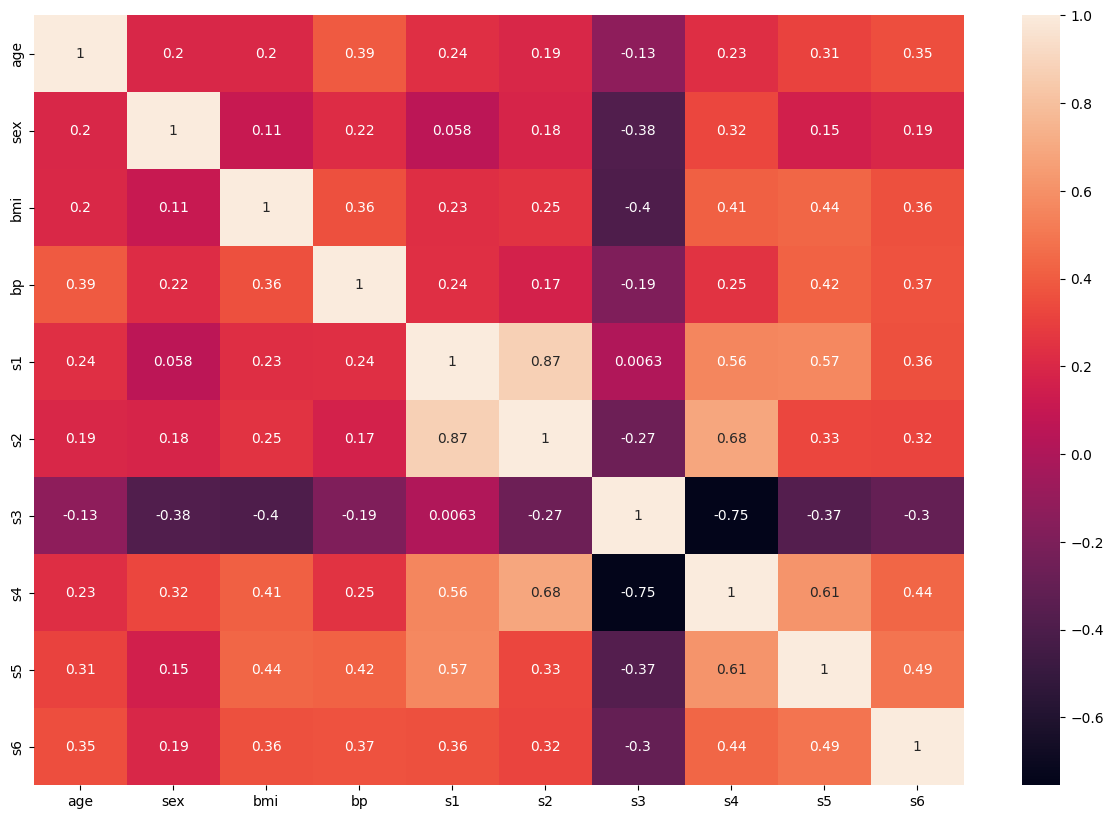

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(), annot=True)

In [0]:
from sklearn.tree import DecisionTreeRegressor

In [0]:
regressor=DecisionTreeRegressor()
regressor.fit(X_train,Y_train)

DecisionTreeRegressor()

 ## HyperParameter tuning

In [0]:
param={
    "criterion":[ "squared_error", "friedman_mse", "absolute_error"],
    "splitter": ["best","random"],
    "max_depth": [1,2,3,4,5,10,15,20,25],
    "max_features":['auto','sqrt','log2']
}

In [0]:
from sklearn.model_selection import GridSearchCV
regressor=DecisionTreeRegressor()

In [0]:
grid=GridSearchCV(regressor, param_grid=param,cv=5, scoring='neg_mean_squared_error')

In [0]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [0]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'random'}

In [0]:
Y_Pred=grid.predict(X_test)

In [0]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(Y_Pred,Y_test))
print("--------------")
print(mean_absolute_error(Y_Pred,Y_test))
print("--------------")
print(mean_squared_error(Y_Pred,Y_test))

-1.6071219999834465
--------------
59.05306203821241
--------------
5242.967599387578


In [0]:
selectedmodel=DecisionTreeRegressor(criterion= 'friedman_mse', max_depth= 4, max_features= 'sqrt', splitter= 'random')

In [0]:
selectedmodel.fit(X_train,Y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                      max_features='sqrt', splitter='random')

[Text(0.5, 0.9, 'x[0] <= 0.023\nfriedman_mse = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.25, 0.7, 'x[2] <= -0.049\nfriedman_mse = 5557.275\nsamples = 196\nvalue = 138.969'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[7] <= -0.03\nfriedman_mse = 1865.532\nsamples = 39\nvalue = 92.513'),
 Text(0.0625, 0.3, 'x[6] <= 0.036\nfriedman_mse = 1358.196\nsamples = 30\nvalue = 83.933'),
 Text(0.03125, 0.1, 'friedman_mse = 1547.917\nsamples = 13\nvalue = 92.077'),
 Text(0.09375, 0.1, 'friedman_mse = 1123.619\nsamples = 17\nvalue = 77.706'),
 Text(0.1875, 0.3, 'x[5] <= 0.013\nfriedman_mse = 2493.432\nsamples = 9\nvalue = 121.111'),
 Text(0.15625, 0.1, 'friedman_mse = 1091.583\nsamples = 6\nvalue = 99.5'),
 Text(0.21875, 0.1, 'friedman_mse = 2494.889\nsamples = 3\nvalue = 164.333'),
 Text(0.375, 0.5, 'x[2] <= 0.137\nfriedman_mse = 5805.04\nsamples = 157\nvalue = 150.51'),
 Text(0.3125, 0.3, 'x[2] <= 0.043\nfriedman_mse = 5565.67\nsamples = 154\nvalue = 148.11'),
 Text(0.28125, 0.1, 

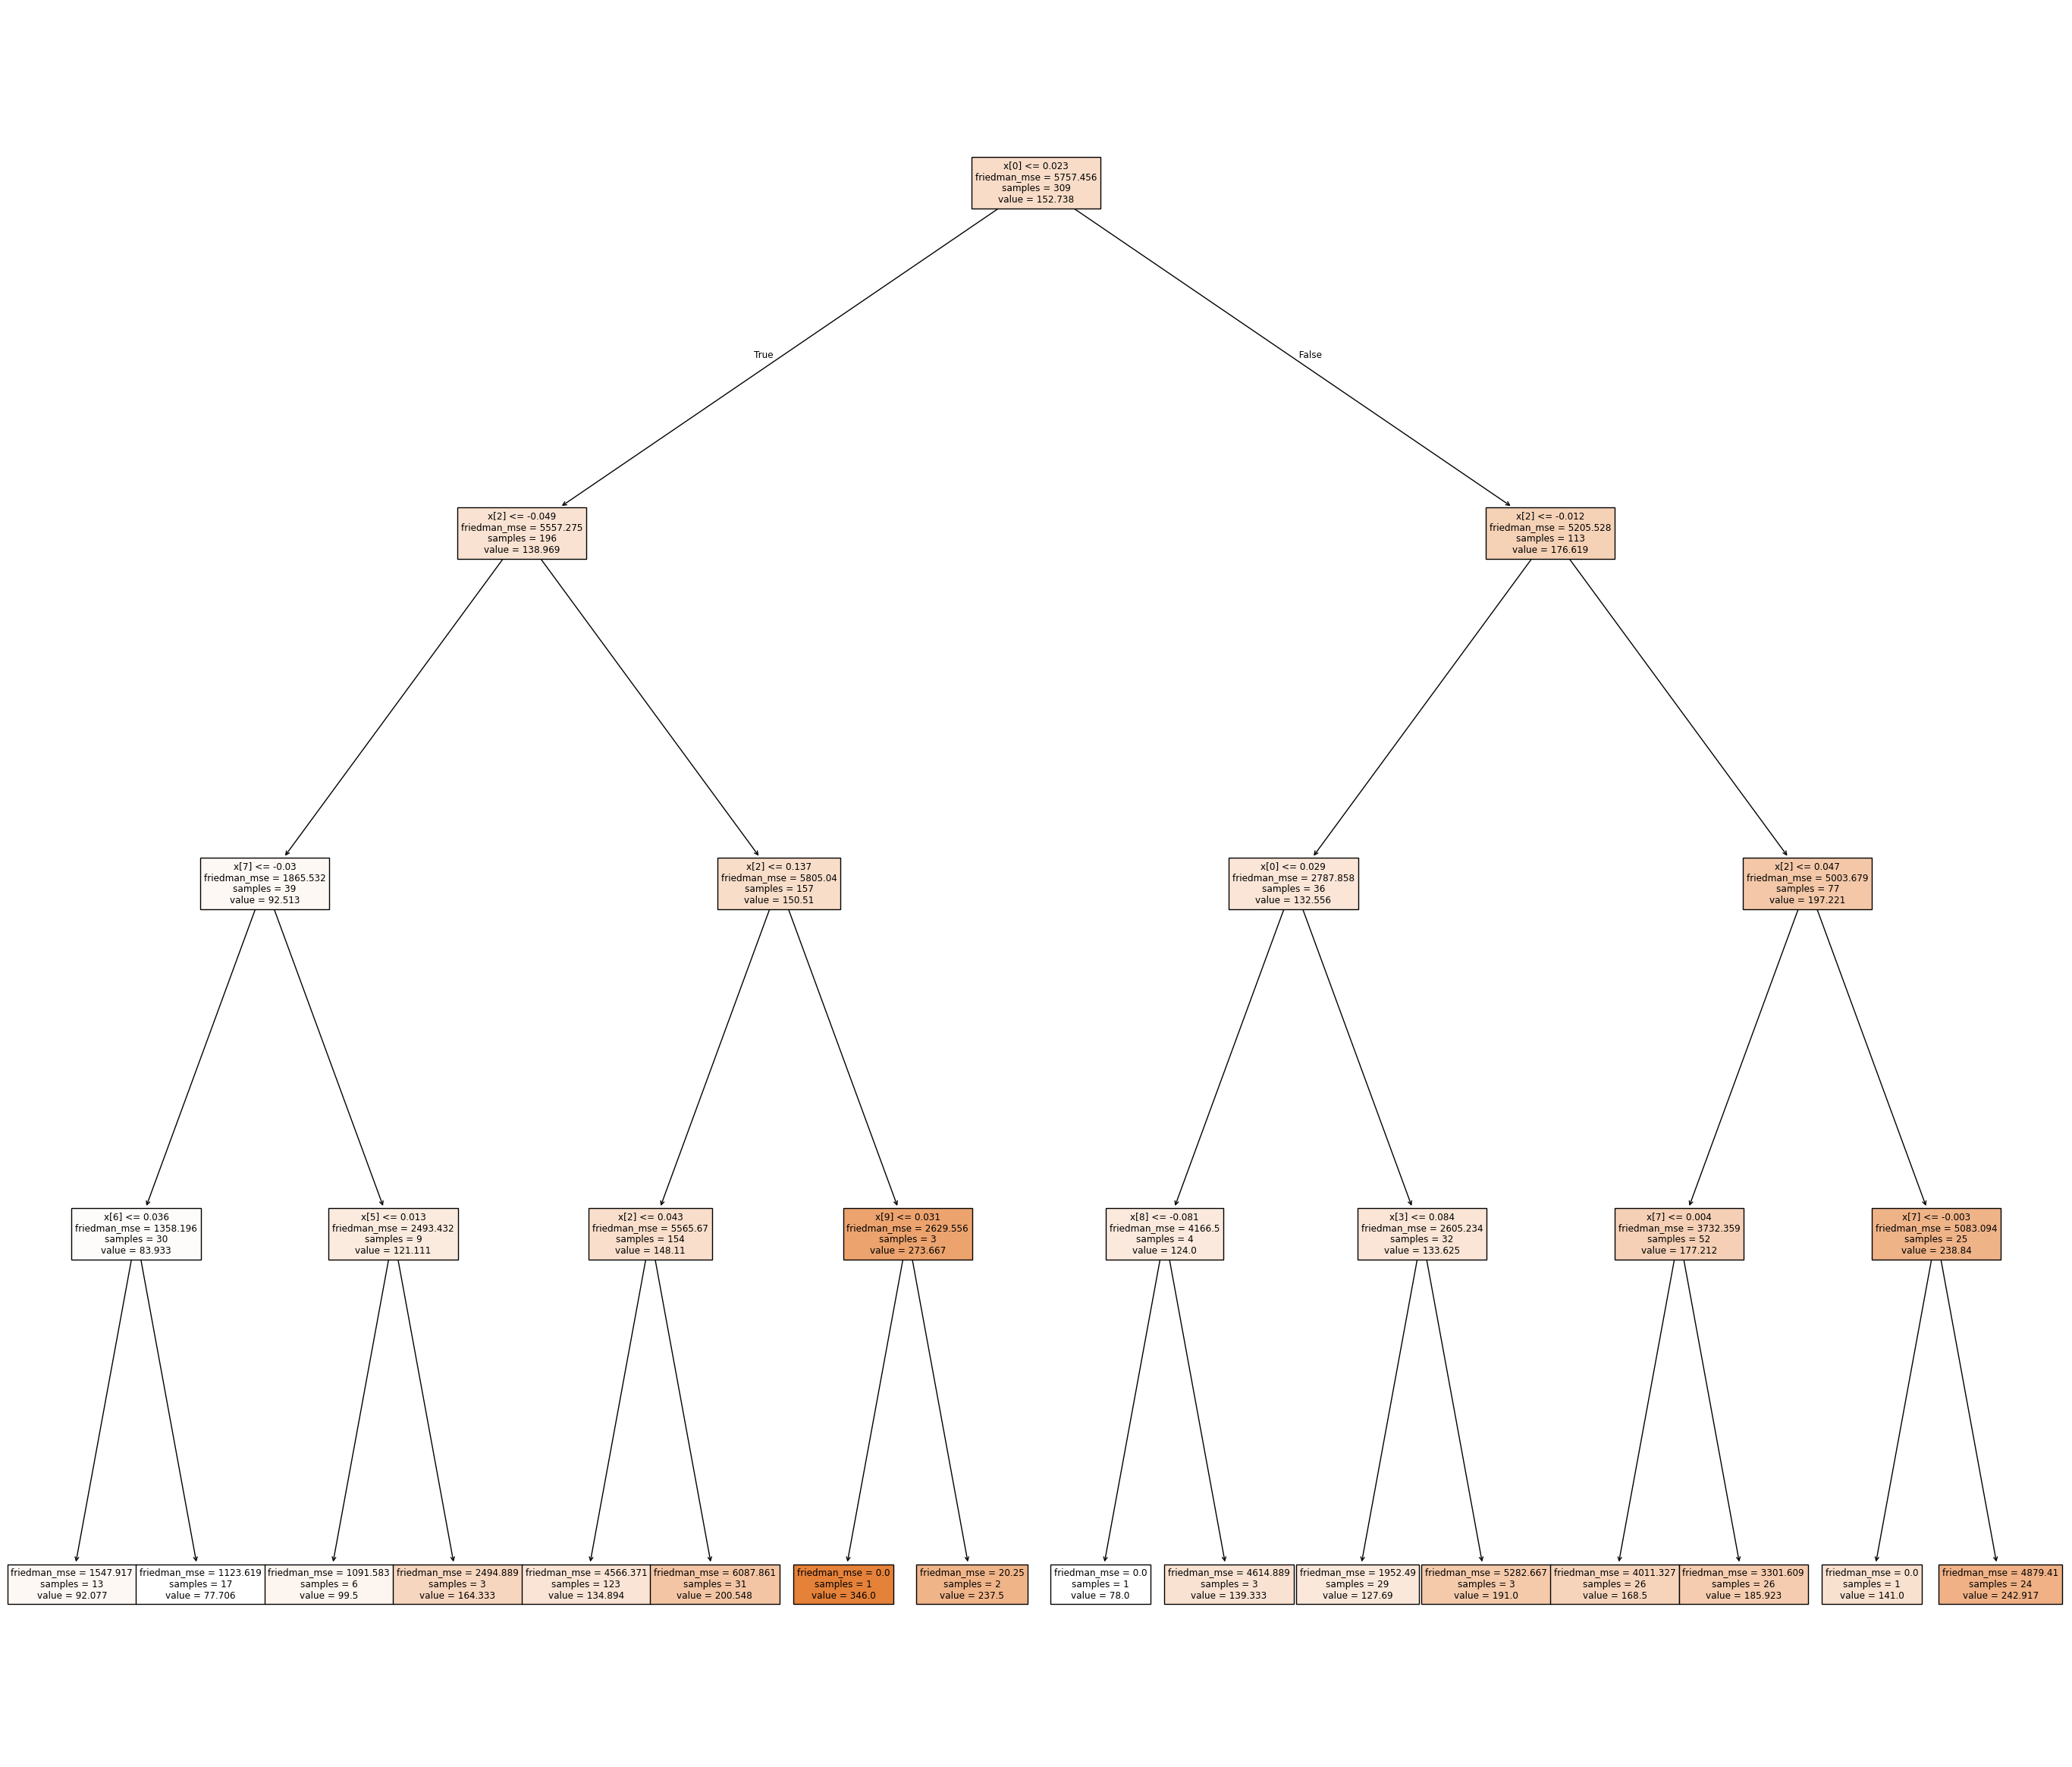

In [0]:
# visualize the tree
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(35,30))
tree.plot_tree(selectedmodel,filled=True)